<a href="https://colab.research.google.com/github/Blossom-75/ObjectDetectionTrackingProject/blob/main/EvaluationMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio
!pip install pandas matplotlib scikit-learn openpyxl
!pip install git+https://github.com/levan92/deep_sort_realtime.git

  Cloning https://github.com/levan92/deep_sort_realtime.git to /tmp/pip-req-build-xpg4vqzs
  Running command git clone --filter=blob:none --quiet https://github.com/levan92/deep_sort_realtime.git /tmp/pip-req-build-xpg4vqzs
  Resolved https://github.com/levan92/deep_sort_realtime.git to commit d1c3656eaeca39d485289617fcb73ffcacb20409
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for deep-sort-realtime: filename=deep_sort_realtime-1.3.2-py3-none-any.whl size=8429413 sha256=2dd8425a417f8d61176acb0d0b206a05393a86794c5cadc9702a9257209d80d3
  Stored in directory: /tmp/pip-ephem-wheel-cache-21sjmekc/wheels/51/9b/cc/30d5fbfa89c6f545e1f0996d03c958ede9a372f61fcd8e2e5b
Successfully built deep-sort-realtime


In [ ]:
from google.colab import files

uploaded = files.upload()  # This will open a file picker

Saving gt.txt to gt (1).txt
Saving tracking_results.xlsx to tracking_results.xlsx


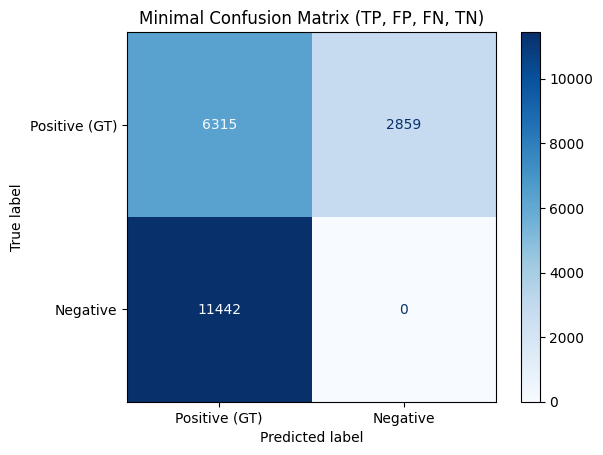

Tracking Accuracy: 30.63%


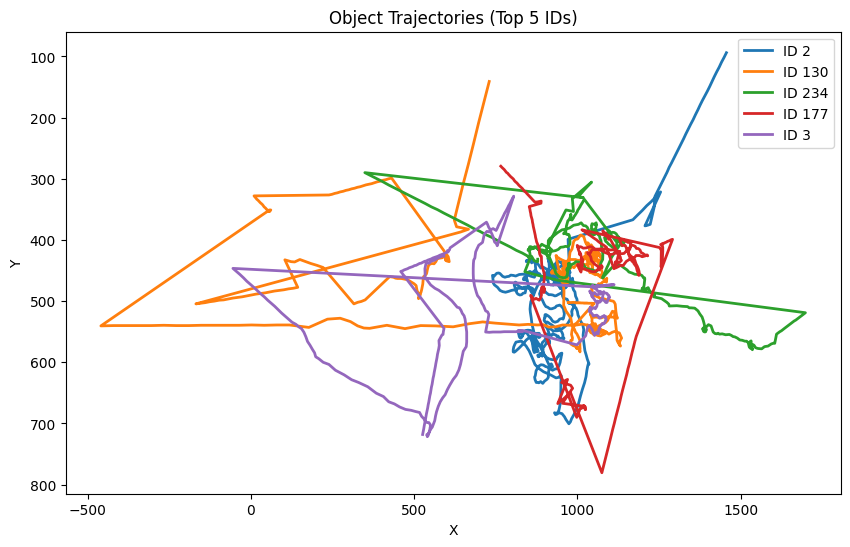

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------- CONFIG ----------------
TRACKING_FILE = "/content/tracking_results.xlsx"  # Your JDE tracking output
GT_FILE = "/content/gt.txt"                      # Ground truth for MOT16 train sequence

# ---------------- LOAD TRACKING & GT ----------------
tracking = pd.read_excel(TRACKING_FILE)

gt_cols = ['Frame','ID','X','Y','W','H','conf','a','b','c']
gt = pd.read_csv(GT_FILE, header=None, names=gt_cols)
gt = gt[gt['conf'] > 0]  # Only visible objects

# Convert GT to x1,y1,x2,y2
gt['X1'] = gt['X']
gt['Y1'] = gt['Y']
gt['X2'] = gt['X'] + gt['W']
gt['Y2'] = gt['Y'] + gt['H']

# ---------------- IoU function ----------------
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB-xA) * max(0, yB-yA)
    boxAArea = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

# ---------------- MATCH TRACKING TO GT ----------------
matches = []
for frame in gt['Frame'].unique():
    gt_frame = gt[gt['Frame']==frame]
    tr_frame = tracking[tracking['Frame']==frame]
    matched_tr_ids = set()
    for _, gt_obj in gt_frame.iterrows():
        best_iou = 0
        best_id = -1
        for _, tr_obj in tr_frame.iterrows():
            iou_val = iou([gt_obj['X1'],gt_obj['Y1'],gt_obj['X2'],gt_obj['Y2']],
                          [tr_obj['X1'],tr_obj['Y1'],tr_obj['X2'],tr_obj['Y2']])
            if iou_val > best_iou:
                best_iou = iou_val
                best_id = tr_obj['ID']
        if best_iou > 0.5:
            matches.append({'GT':1,'Pred':1})
            matched_tr_ids.add(best_id)
        else:
            matches.append({'GT':1,'Pred':0})  # FN

    # Unmatched predicted IDs are FP
    for _, tr_obj in tr_frame.iterrows():
        if tr_obj['ID'] not in matched_tr_ids:
            matches.append({'GT':0,'Pred':1})

matches_df = pd.DataFrame(matches)

# ---------------- MINIMAL CONFUSION MATRIX ----------------
cm = confusion_matrix(matches_df['GT'], matches_df['Pred'], labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive (GT)','Negative'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Minimal Confusion Matrix (TP, FP, FN, TN)")
plt.show()

accuracy = (cm[0,0]+cm[1,1])/cm.sum()
print(f"Tracking Accuracy: {accuracy*100:.2f}%")

# ---------------- NEAT TRAJECTORY PLOT ----------------
plt.figure(figsize=(10,6))
top_tracks = tracking['ID'].value_counts().index[:5]  # Top 5 tracks
for track_id in top_tracks:
    track = tracking[tracking['ID']==track_id]
    plt.plot((track['X1']+track['X2'])/2, (track['Y1']+track['Y2'])/2, label=f'ID {track_id}', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Object Trajectories (Top 5 IDs)')
plt.legend()
plt.show()
